<a href="https://colab.research.google.com/github/rahulsharma-crtl/Terra_watch/blob/main/Major_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.datasets import EuroSAT
from torchvision.models import resnet18, ResNet18_Weights


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


In [3]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

raw_transform = transforms.Compose([
    transforms.Resize((128, 128)),
])

In [4]:
DATA_ROOT = "/content/eurosat_data"

dataset = EuroSAT(
    root=DATA_ROOT,
    download=True,
    transform=train_transform
)

raw_dataset = EuroSAT(
    root=DATA_ROOT,
    download=False,
    transform=raw_transform
)

class_names = dataset.classes
num_classes = len(class_names)

print("Dataset size:", len(dataset))
print("Classes:", class_names)

100%|██████████| 94.3M/94.3M [00:00<00:00, 296MB/s]


Dataset size: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [5]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(
    dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

TRAIN_LIMIT = 8000
train_indices = train_dataset.indices[:TRAIN_LIMIT]
train_dataset_small = Subset(dataset, train_indices)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset_small,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 500
Test batches: 338


In [6]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)

model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 39.9MB/s]


Linear(in_features=512, out_features=10, bias=True)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 2

In [8]:
print("Starting training...")

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if (batch_idx + 1) % 100 == 0:
            print(
                f"Epoch {epoch + 1}/{EPOCHS}, "
                f"Batch {batch_idx + 1}/{len(train_loader)}, "
                f"Loss: {loss.item():.4f}"
            )

    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total

    print(f"Epoch {epoch + 1} finished")
    print(f"Training Loss: {epoch_loss:.4f}")
    print(f"Training Accuracy: {epoch_acc:.2f}%")

print("Final training accuracy:", round(epoch_acc, 2), "%")

Starting training...
Epoch 1/2, Batch 100/500, Loss: 0.6644
Epoch 1/2, Batch 200/500, Loss: 0.4573
Epoch 1/2, Batch 300/500, Loss: 0.5751
Epoch 1/2, Batch 400/500, Loss: 0.1036
Epoch 1/2, Batch 500/500, Loss: 0.2583
Epoch 1 finished
Training Loss: 0.3981
Training Accuracy: 87.34%
Epoch 2/2, Batch 100/500, Loss: 0.0727
Epoch 2/2, Batch 200/500, Loss: 0.0677
Epoch 2/2, Batch 300/500, Loss: 0.1326
Epoch 2/2, Batch 400/500, Loss: 0.0914
Epoch 2/2, Batch 500/500, Loss: 0.3956
Epoch 2 finished
Training Loss: 0.1498
Training Accuracy: 95.15%
Final training accuracy: 95.15 %


In [9]:
inference_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

def load_image_for_model(image_path):
    pil_img = Image.open(image_path).convert("RGB")
    tensor = inference_transform(pil_img).unsqueeze(0)
    return pil_img, tensor


def predict_land_use(image_path):
    model.eval()

    _, image_tensor = load_image_for_model(image_path)
    image_tensor = image_tensor.to(device)

    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.softmax(logits, dim=1)[0]

    pred_idx = int(torch.argmax(probs).item())
    pred_label = class_names[pred_idx]
    confidence = float(probs[pred_idx].item())

    return pred_idx, pred_label, confidence, probs.detach().cpu().numpy()

In [10]:
def detect_land_use_change(image_path_old, image_path_new):
    old_idx, old_label, old_conf, old_probs = predict_land_use(image_path_old)
    new_idx, new_label, new_conf, new_probs = predict_land_use(image_path_new)

    print("=" * 60)
    print("TerraWatch Difference Analysis Report")
    print("=" * 60)

    print(f"Old snapshot: {old_label} | Confidence: {old_conf * 100:.2f}%")
    print(f"New snapshot: {new_label} | Confidence: {new_conf * 100:.2f}%")

    if old_label != new_label:
        print(
            f"\nLand-use changed from "
            f"{old_conf * 100:.2f}% {old_label} "
            f"to {new_conf * 100:.2f}% {new_label}"
        )
    else:
        print(f"\nNo major class shift detected. Both are {old_label}.")

    print("\nTop probability differences:")

    prob_diffs = new_probs - old_probs
    ranked = np.argsort(np.abs(prob_diffs))[::-1][:5]

    for idx in ranked:
        print(
            f"{class_names[idx]:20s}: "
            f"{old_probs[idx] * 100:6.2f}% -> "
            f"{new_probs[idx] * 100:6.2f}% "
            f"({prob_diffs[idx] * 100:+6.2f}%)"
        )

    print("=" * 60)

In [11]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self.forward_hook = self.target_layer.register_forward_hook(
            self._save_activations
        )

        self.backward_hook = self.target_layer.register_full_backward_hook(
            self._save_gradients
        )

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        self.model.zero_grad()

        logits = self.model(image_tensor)

        if class_idx is None:
            class_idx = int(logits.argmax(dim=1).item())

        score = logits[:, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)

        cam = torch.nn.functional.interpolate(
            cam,
            size=(128, 128),
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze().detach().cpu().numpy()

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam, class_idx

    def close(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

In [12]:



def create_gradcam_overlay(image_path, gradcam):
    pil_img, image_tensor = load_image_for_model(image_path)
    image_tensor = image_tensor.to(device)

    pred_idx, pred_label, confidence, _ = predict_land_use(image_path)

    heatmap, _ = gradcam.generate(image_tensor, class_idx=pred_idx)

    display_img = pil_img.resize((128, 128))
    display_np = np.array(display_img).astype(np.float32) / 255.0

    return display_np, heatmap, pred_label, confidence


def plot_temporal_gradcam(image_path_old, image_path_new):
    target_layer = model.layer4[-1].conv2
    gradcam = GradCAM(model, target_layer)

    old_img, old_heatmap, old_label, old_conf = create_gradcam_overlay(
        image_path_old,
        gradcam
    )

    new_img, new_heatmap, new_label, new_conf = create_gradcam_overlay(
        image_path_new,
        gradcam
    )

    gradcam.close()

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))

    axes[0, 0].imshow(old_img)
    axes[0, 0].set_title(f"Old Image\n{old_label} ({old_conf * 100:.1f}%)")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(new_img)
    axes[0, 1].set_title(f"New Image\n{new_label} ({new_conf * 100:.1f}%)")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(old_img)
    axes[1, 0].imshow(old_heatmap, cmap="jet", alpha=0.45)
    axes[1, 0].set_title("Old Grad-CAM Evidence")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(new_img)
    axes[1, 1].imshow(new_heatmap, cmap="jet", alpha=0.45)
    axes[1, 1].set_title("New Grad-CAM Evidence")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

In [13]:
sample_dir = "/content/terrawatch_mock_samples"
os.makedirs(sample_dir, exist_ok=True)

test_indices = test_dataset.indices

old_raw_idx = test_indices[0]
new_raw_idx = test_indices[25]

old_pil, old_true_label = raw_dataset[old_raw_idx]
new_pil, new_true_label = raw_dataset[new_raw_idx]

old_path = os.path.join(sample_dir, "old_snapshot_2020.png")
new_path = os.path.join(sample_dir, "new_snapshot_2024.png")

old_pil.save(old_path)
new_pil.save(new_path)

print("Old image path:", old_path)
print("New image path:", new_path)

print("Old true EuroSAT label:", class_names[old_true_label])
print("New true EuroSAT label:", class_names[new_true_label])

Old image path: /content/terrawatch_mock_samples/old_snapshot_2020.png
New image path: /content/terrawatch_mock_samples/new_snapshot_2024.png
Old true EuroSAT label: Forest
New true EuroSAT label: SeaLake


In [14]:
detect_land_use_change(old_path, new_path)

TerraWatch Difference Analysis Report
Old snapshot: Forest | Confidence: 99.69%
New snapshot: SeaLake | Confidence: 99.72%

Land-use changed from 99.69% Forest to 99.72% SeaLake

Top probability differences:
SeaLake             :   0.00% ->  99.72% (+99.71%)
Forest              :  99.69% ->   0.14% (-99.55%)
Pasture             :   0.26% ->   0.00% ( -0.26%)
AnnualCrop          :   0.00% ->   0.13% ( +0.13%)
HerbaceousVegetation:   0.04% ->   0.00% ( -0.04%)


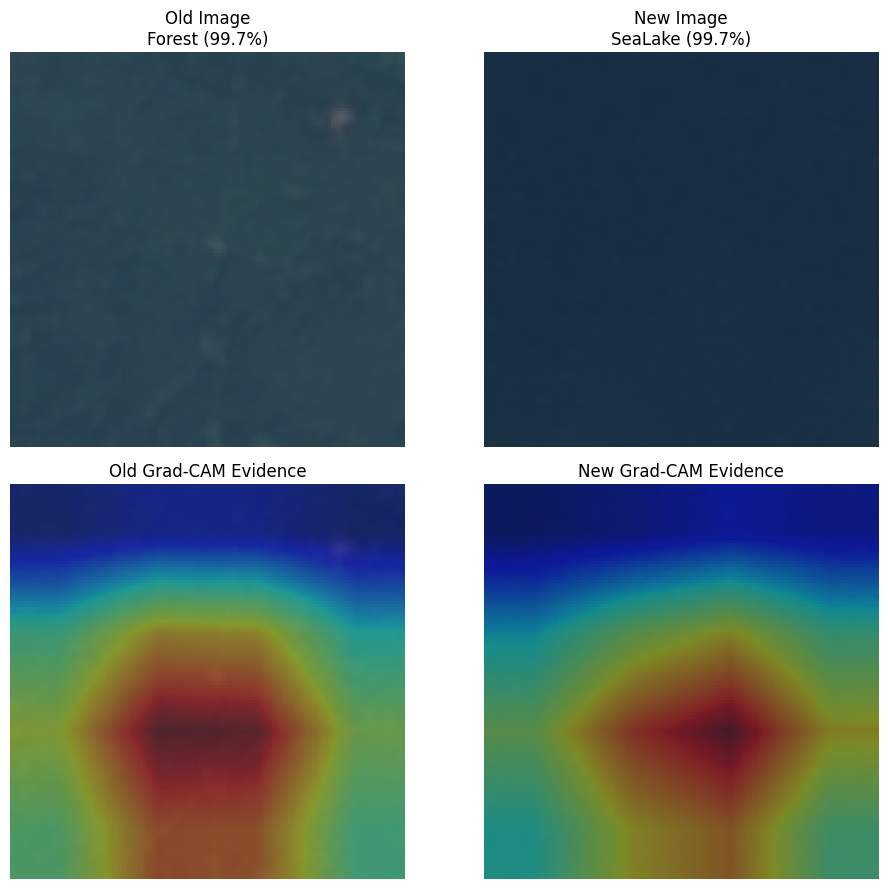

In [15]:
plot_temporal_gradcam(old_path, new_path)

In [16]:
from google.colab import files

uploaded = files.upload()

Saving forest1.png to forest1.png
Saving forest2.png to forest2.png


In [17]:
old_path = "/content/forest1.png"
new_path = "/content/forest2.png"

print("Old image:", old_path)
print("New image:", new_path)

Old image: /content/forest1.png
New image: /content/forest2.png


TerraWatch Difference Analysis Report
Old snapshot: AnnualCrop | Confidence: 98.32%
New snapshot: Residential | Confidence: 81.08%

Land-use changed from 98.32% AnnualCrop to 81.08% Residential

Top probability differences:
AnnualCrop          :  98.32% ->   5.07% (-93.25%)
Residential         :   0.38% ->  81.08% (+80.71%)
PermanentCrop       :   1.14% ->  13.50% (+12.37%)
Pasture             :   0.01% ->   0.10% ( +0.10%)
Forest              :   0.01% ->   0.07% ( +0.06%)


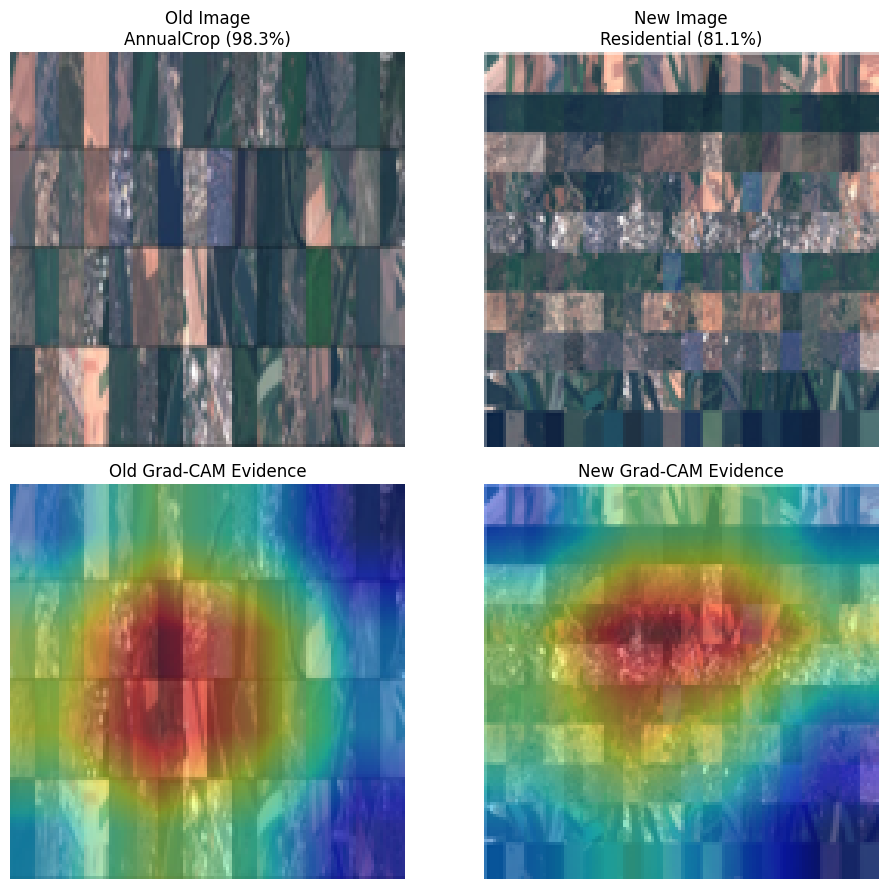

In [18]:
detect_land_use_change(old_path, new_path)
plot_temporal_gradcam(old_path, new_path)